# ETL Pipeline: New York City Airbnb Open Data

**Dataset**: New York City Airbnb Open Data (AB_NYC_2019.csv)

**Tujuan**:
- Extract: Membaca data dari file CSV
- Transform: Membersihkan dan memformat data
- Load: Menyimpan data bersih ke file baru

---

## 1. Import Libraries

Import library Pandas yang dibutuhkan untuk proses ETL.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings

# Ignore warnings untuk output yang lebih bersih
warnings.filterwarnings('ignore')

print("✓ Library Pandas berhasil di-import")

✓ Library Pandas berhasil di-import


---
## Tahap 2: Extract (Membaca Data)

Pada tahap ini kita akan:
1. Membaca dataset dari file CSV
2. Menampilkan informasi dasar tentang dataset
3. Melihat sample data

In [2]:
# Membaca dataset
df = pd.read_csv('../tugas-etl-airbnb/data/raw/AB_NYC_2019.csv')

print(f"Dataset berhasil dimuat!")
print(f"Jumlah baris: {df.shape[0]:,}")
print(f"Jumlah kolom: {df.shape[1]}")

Dataset berhasil dimuat!
Jumlah baris: 48,895
Jumlah kolom: 16


In [3]:
# Menampilkan 5 baris pertama
print("\n=== 5 BARIS PERTAMA DARI DATASET ===")
df.head()


=== 5 BARIS PERTAMA DARI DATASET ===


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
# Menampilkan informasi dataset
print("\n=== INFORMASI DATASET ===")
df.info()


=== INFORMASI DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review     

In [5]:
# Menampilkan statistik deskriptif
print("\n=== STATISTIK DESKRIPTIF ===")
df.describe()


=== STATISTIK DESKRIPTIF ===


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


---
## Tahap 3: Transform (Data Cleaning)

Pada tahap ini kita akan membersihkan data dengan langkah-langkah:
1. **Handling Missing Values** - Menangani nilai kosong
2. **Data Formatting** - Memperbaiki format data
3. **Data Filtering** - Menghapus data yang tidak relevan atau anomali

### 3.1 Handling Missing Values

**Alasan**: Nilai kosong (null/NaN) dapat mengganggu analisis dan visualisasi. Kita perlu menanganinya dengan cara yang sesuai untuk setiap kolom.

In [6]:
# Memeriksa jumlah nilai kosong di setiap kolom
print("=== JUMLAH NILAI KOSONG PER KOLOM ===")
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Jumlah Missing': missing_values,
    'Persentase (%)': missing_percent
})

missing_df = missing_df[missing_df['Jumlah Missing'] > 0].sort_values('Jumlah Missing', ascending=False)
print(missing_df)

=== JUMLAH NILAI KOSONG PER KOLOM ===
                   Jumlah Missing  Persentase (%)
reviews_per_month           10052       20.558339
last_review                 10052       20.558339
host_name                      21        0.042949
name                           16        0.032723


In [7]:
# Simpan jumlah data sebelum cleaning
rows_before = df.shape[0]
print(f"Jumlah baris sebelum cleaning: {rows_before:,}")

Jumlah baris sebelum cleaning: 48,895


**Langkah 1**: Mengisi nilai kosong pada kolom `reviews_per_month` dengan 0.

**Alasan**: Jika tidak ada review, maka secara logis reviews per month adalah 0 (bukan data yang hilang).

In [8]:
# Mengisi nilai kosong pada reviews_per_month dengan 0
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

print(f"✓ Nilai kosong pada 'reviews_per_month' telah diisi dengan 0")
print(f"  Missing values sekarang: {df['reviews_per_month'].isnull().sum()}")

✓ Nilai kosong pada 'reviews_per_month' telah diisi dengan 0
  Missing values sekarang: 0


**Langkah 2**: Menghapus baris yang memiliki nilai kosong pada kolom `name` atau `host_name`.

**Alasan**: Kolom `name` (nama listing) dan `host_name` (nama pemilik) adalah informasi identitas yang penting. Data tanpa informasi ini dianggap tidak valid untuk analisis bisnis.

In [9]:
# Menghapus baris dengan nilai kosong pada 'name' atau 'host_name'
df = df.dropna(subset=['name', 'host_name'])

rows_after = df.shape[0]
rows_dropped = rows_before - rows_after

print(f"✓ Baris dengan 'name' atau 'host_name' kosong telah dihapus")
print(f"  Jumlah baris dihapus: {rows_dropped}")
print(f"  Jumlah baris sekarang: {rows_after:,}")

✓ Baris dengan 'name' atau 'host_name' kosong telah dihapus
  Jumlah baris dihapus: 37
  Jumlah baris sekarang: 48,858


### 3.2 Data Formatting

**Alasan**: Tipe data yang benar memudahkan operasi dan analisis. Kolom tanggal harus dalam format datetime agar bisa dilakukan operasi temporal.

In [10]:
# Mengubah kolom last_review menjadi datetime
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

print(f"✓ Kolom 'last_review' telah diubah ke format datetime")
print(f"  Tipe data sekarang: {df['last_review'].dtype}")
print(f"\nContoh data:")
print(df[['name', 'last_review']].head())

✓ Kolom 'last_review' telah diubah ke format datetime
  Tipe data sekarang: datetime64[us]

Contoh data:
                                               name last_review
0                Clean & quiet apt home by the park  2018-10-19
1                             Skylit Midtown Castle  2019-05-21
2               THE VILLAGE OF HARLEM....NEW YORK !         NaT
3                   Cozy Entire Floor of Brownstone  2019-07-05
4  Entire Apt: Spacious Studio/Loft by central park  2018-11-19


### 3.3 Data Filtering

Menghapus kolom dan baris yang tidak relevan atau mengandung anomali.

**Langkah 1**: Menghapus kolom `id` dan `host_name`.

**Alasan**: 
- `id`: Hanya identifier unik, tidak memberikan insight untuk analisis bisnis
- `host_name`: Informasi nama personal yang tidak relevan untuk analisis agregat dan berpotensi menimbulkan isu privasi

In [11]:
# Menghapus kolom yang tidak relevan
columns_to_drop = ['id', 'host_name']
df = df.drop(columns=columns_to_drop)

print(f"✓ Kolom {columns_to_drop} telah dihapus")
print(f"  Jumlah kolom sekarang: {df.shape[1]}")

✓ Kolom ['id', 'host_name'] telah dihapus
  Jumlah kolom sekarang: 14


**Langkah 2**: Menghapus baris dengan harga (price) = 0.

**Alasan**: Harga sewa $0 adalah anomali karena tidak masuk akal secara bisnis. Kemungkinan ini adalah data error atau listing yang tidak aktif.

In [12]:
# Melihat distribusi harga sebelum filtering
print("=== STATISTIK HARGA SEBELUM FILTERING ===")
print(f"Jumlah listing dengan harga = 0: {(df['price'] == 0).sum()}")
print(f"Harga minimum: ${df['price'].min()}")
print(f"Harga maksimum: ${df['price'].max():,.0f}")
print(f"Harga rata-rata: ${df['price'].mean():.2f}")

=== STATISTIK HARGA SEBELUM FILTERING ===
Jumlah listing dengan harga = 0: 11
Harga minimum: $0
Harga maksimum: $10,000
Harga rata-rata: $152.74


In [13]:
# Menghapus baris dengan price = 0
rows_before_price = df.shape[0]
df = df[df['price'] > 0]
rows_after_price = df.shape[0]
rows_dropped_price = rows_before_price - rows_after_price

print(f"\n✓ Baris dengan harga = 0 telah dihapus")
print(f"  Jumlah baris dihapus: {rows_dropped_price}")
print(f"  Jumlah baris sekarang: {rows_after_price:,}")


✓ Baris dengan harga = 0 telah dihapus
  Jumlah baris dihapus: 11
  Jumlah baris sekarang: 48,847


In [14]:
# Ringkasan hasil cleaning
print("\n" + "="*50)
print("RINGKASAN PROSES DATA CLEANING")
print("="*50)
print(f"Dataset awal      : {rows_before:,} baris x {df.shape[1] + 2} kolom")
print(f"Dataset akhir     : {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"Total baris dihapus: {rows_before - df.shape[0]:,} ({((rows_before - df.shape[0])/rows_before*100):.2f}%)")
print(f"\nKolom yang dihapus: {columns_to_drop}")
print(f"Nilai kosong tersisa: {df.isnull().sum().sum()}")
print("="*50)


RINGKASAN PROSES DATA CLEANING
Dataset awal      : 48,895 baris x 16 kolom
Dataset akhir     : 48,847 baris x 14 kolom
Total baris dihapus: 48 (0.10%)

Kolom yang dihapus: ['id', 'host_name']
Nilai kosong tersisa: 10036


In [15]:
# Melihat preview data yang sudah bersih
print("\n=== PREVIEW DATA YANG SUDAH DIBERSIHKAN ===")
df.head(10)


=== PREVIEW DATA YANG SUDAH DIBERSIHKAN ===


,name,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,Clean & quiet apt home by the park,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,Skylit Midtown Castle,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,THE VILLAGE OF HARLEM....NEW YORK !,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365
3,Cozy Entire Floor of Brownstone,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,Entire Apt: Spacious Studio/Loft by central park,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,Large Cozy 1 BR Apartment In Midtown East,7322,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
6,BlissArtsSpace!,7356,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.40,1,0
7,Large Furnished Room Near B'way,8967,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,2019-06-24,3.47,1,220
8,Cozy Clean Guest Room - Family Apt,7490,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
9,Cute & Cozy Lower East Side 1 bdrm,7549,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,2019-06-09,1.33,4,188


---
## Tahap 4: Visualisasi Data Sederhana

Membuat visualisasi untuk mendapatkan insight dasar dari data.

### 4.1 Bar Chart: Rata-rata Harga Sewa per Wilayah

**Tujuan**: Mengetahui wilayah mana yang memiliki harga sewa rata-rata tertinggi dan terendah.

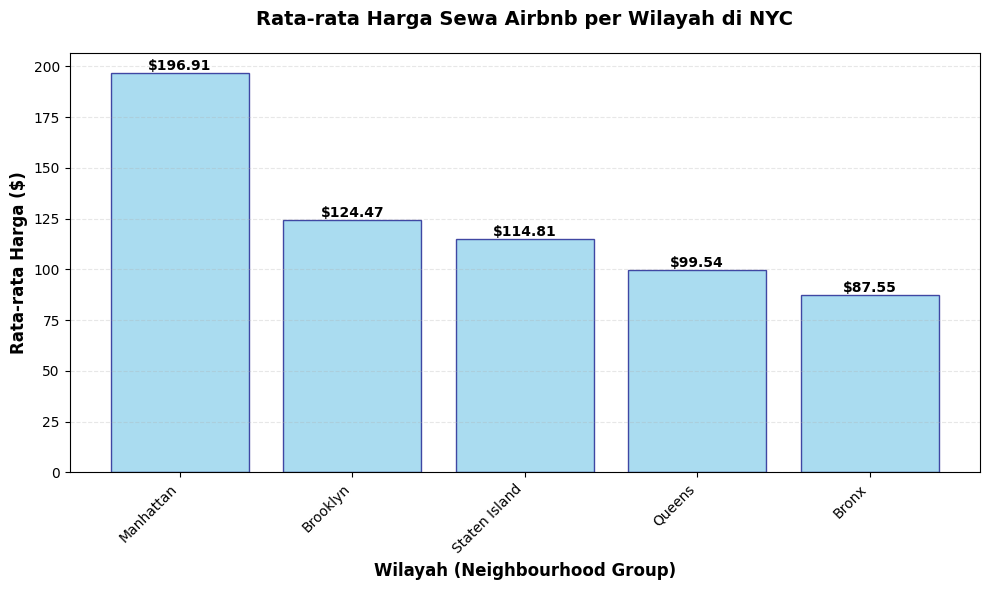


=== RATA-RATA HARGA PER WILAYAH ===
Manhattan           : $ 196.91
Brooklyn            : $ 124.47
Staten Island       : $ 114.81
Queens              : $  99.54
Bronx               : $  87.55


In [16]:
# Menghitung rata-rata harga per neighbourhood_group
avg_price_by_area = df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)

# Membuat bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(avg_price_by_area.index, avg_price_by_area.values, color='skyblue', edgecolor='navy', alpha=0.7)

# Menambahkan nilai di atas setiap bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:.2f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Rata-rata Harga Sewa Airbnb per Wilayah di NYC', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Wilayah (Neighbourhood Group)', fontsize=12, fontweight='bold')
plt.ylabel('Rata-rata Harga ($)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\n=== RATA-RATA HARGA PER WILAYAH ===")
for area, price in avg_price_by_area.items():
    print(f"{area:20s}: ${price:7.2f}")

### 4.2 Scatter Plot: Pemetaan Lokasi Penyewaan

**Tujuan**: Visualisasi geografis untuk melihat distribusi listing Airbnb di NYC berdasarkan lokasi dan wilayah.

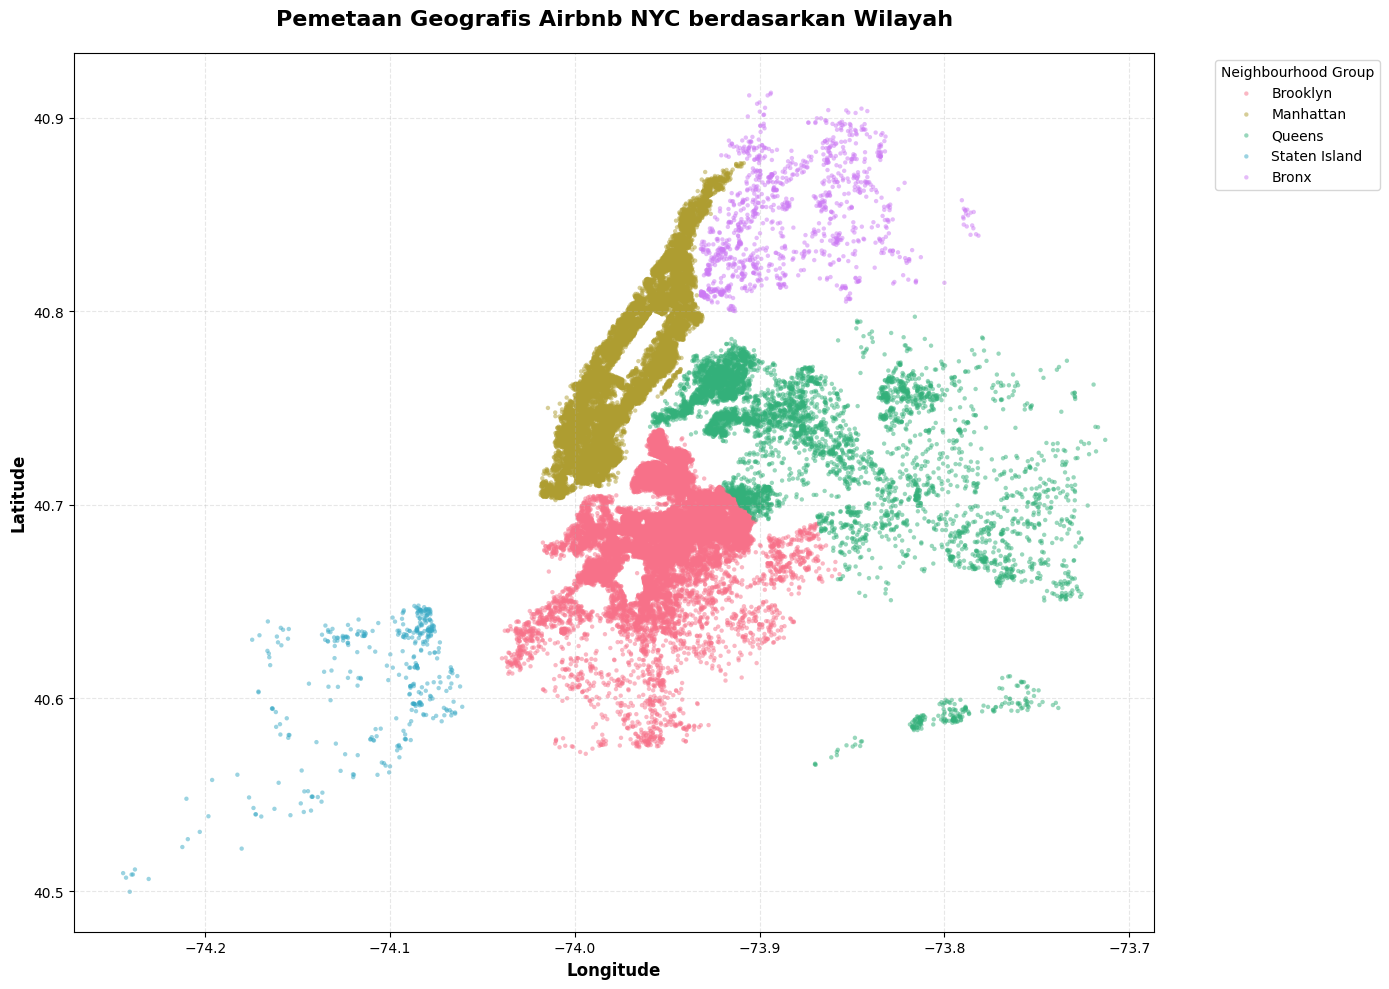


=== DISTRIBUSI LISTING PER WILAYAH ===
Manhattan           : 21,642 listing (44.31%)
Brooklyn            : 20,080 listing (41.11%)
Queens              :  5,664 listing (11.60%)
Bronx               :  1,088 listing ( 2.23%)
Staten Island       :    373 listing ( 0.76%)


In [17]:
# Membuat scatter plot
plt.figure(figsize=(14, 10))

# Mendapatkan warna unik untuk setiap neighbourhood_group
groups = df['neighbourhood_group'].unique()
colors = sns.color_palette('husl', n_colors=len(groups))

for i, group in enumerate(groups):
    group_data = df[df['neighbourhood_group'] == group]
    plt.scatter(group_data['longitude'], 
               group_data['latitude'],
               c=[colors[i]], 
               label=group,
               alpha=0.5,
               s=10,
               edgecolors='none')

plt.title('Pemetaan Geografis Airbnb NYC berdasarkan Wilayah', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Longitude', fontsize=12, fontweight='bold')
plt.ylabel('Latitude', fontsize=12, fontweight='bold')
plt.legend(title='Neighbourhood Group', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\n=== DISTRIBUSI LISTING PER WILAYAH ===")
distribution = df['neighbourhood_group'].value_counts().sort_values(ascending=False)
for area, count in distribution.items():
    percentage = (count / len(df)) * 100
    print(f"{area:20s}: {count:6,} listing ({percentage:5.2f}%)")

### 4.3 Insight Tambahan: Room Type Distribution

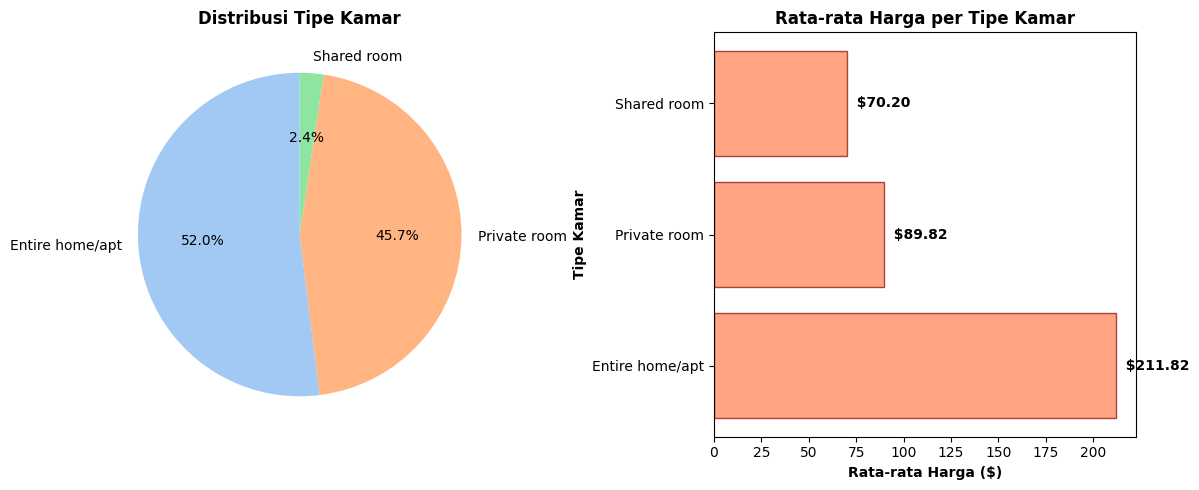

In [18]:
# Visualisasi distribusi tipe kamar
plt.figure(figsize=(12, 5))

# Subplot 1: Pie chart
plt.subplot(1, 2, 1)
room_type_dist = df['room_type'].value_counts()
plt.pie(room_type_dist.values, labels=room_type_dist.index, autopct='%1.1f%%', 
        startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribusi Tipe Kamar', fontsize=12, fontweight='bold')

# Subplot 2: Harga rata-rata per tipe kamar
plt.subplot(1, 2, 2)
avg_price_room = df.groupby('room_type')['price'].mean().sort_values(ascending=False)
bars = plt.barh(avg_price_room.index, avg_price_room.values, color='coral', edgecolor='darkred', alpha=0.7)
plt.xlabel('Rata-rata Harga ($)', fontsize=10, fontweight='bold')
plt.ylabel('Tipe Kamar', fontsize=10, fontweight='bold')
plt.title('Rata-rata Harga per Tipe Kamar', fontsize=12, fontweight='bold')

# Menambahkan nilai
for i, (idx, val) in enumerate(avg_price_room.items()):
    plt.text(val, i, f'  ${val:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## Tahap 5: Load (Menyimpan Data Bersih)

Menyimpan dataset yang sudah dibersihkan ke file CSV baru untuk analisis lebih lanjut.

In [19]:
# Menyimpan data yang sudah dibersihkan
output_path = '../tugas-etl-airbnb/data/clean/airbnb_cleaned.csv'
df.to_csv(output_path, index=False)

print("="*60)
print("✓ DATA BERHASIL DISIMPAN!")
print("="*60)
print(f"Lokasi file: {output_path}")
print(f"Jumlah baris: {df.shape[0]:,}")
print(f"Jumlah kolom: {df.shape[1]}")
print(f"\nKolom yang tersimpan:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")
print("="*60)

✓ DATA BERHASIL DISIMPAN!
Lokasi file: ../tugas-etl-airbnb/data/clean/airbnb_cleaned.csv
Jumlah baris: 48,847
Jumlah kolom: 14

Kolom yang tersimpan:
   1. name
   2. host_id
   3. neighbourhood_group
   4. neighbourhood
   5. latitude
   6. longitude
   7. room_type
   8. price
   9. minimum_nights
  10. number_of_reviews
  11. last_review
  12. reviews_per_month
  13. calculated_host_listings_count
  14. availability_365


---
## Kesimpulan & Insight

Berdasarkan proses ETL dan visualisasi yang telah dilakukan, berikut adalah kesimpulan utama:

### 📊 Insight Harga:
1. **Manhattan** adalah wilayah dengan harga sewa rata-rata tertinggi
2. **Bronx** memiliki harga sewa rata-rata terendah
3. Terdapat variasi harga yang signifikan antar wilayah, mencerminkan perbedaan lokasi dan fasilitas

### 📍 Insight Geografis:
1. **Manhattan dan Brooklyn** memiliki konsentrasi listing terbanyak
2. Distribusi listing mengikuti pola geografis yang jelas sesuai pembagian borough NYC
3. Pemetaan menunjukkan clustering listing di area pusat kota

### 🏠 Insight Tipe Kamar:
1. Sebagian besar listing adalah **Entire home/apt** dan **Private room**
2. **Entire home/apt** memiliki harga rata-rata tertinggi
3. **Shared room** memiliki harga paling terjangkau

### ✅ Proses Data Cleaning:
- Data yang hilang berhasil ditangani dengan metode yang sesuai
- Anomali harga (price = 0) telah dihapus
- Format data telah disesuaikan untuk kemudahan analisis
- Dataset siap untuk analisis lanjutan atau modeling